# Intro

This notebook introduces the behavioral dataset and walks through how the data is cleaned before any analysis is performed. Here, the focus is on the subject's pushes and less so on continuous variables, such as gaze and position.

## Setup

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import logging
import os
import pickle

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

pd.options.mode.copy_on_write = True

from foraging.utils import INDEX, MIN_INDEX
from foraging.utils.data import make_df, display_df, filter_df, get_blocks, get_continuous_from_df_to_dict, \
    exclusion_criteria
from foraging.plotting import bp, titler, enhanced_violinplot, PALETTE, PALETTE_DARK
from foraging.plotting.behavior import plot_pushes, plot_block_events, plot_experiment_parameters, plot_experiment_overview, \
    plot_continuous3d_dict, plot_continuous3d_df, plot_continuous2d_df

# Filter out annoying matplotlib logs
mlogger = logging.getLogger('matplotlib')
mlogger.setLevel(logging.WARNING)

EXPERIMENT_DIR = '../data/experiments'
ANALYSIS_DIR = '../data/analysis'
FIGURES_DIR = '../figures'
SEED = 42

# Load Data

The experiment data consists of multiple matfiles corresponding to the data for different subjects. Each matfile contains that subject's push, eye tracking (if available), and position (if available) data organized by blocks and sessions. Each block corresponds to a set of experiment parameters, notably the schedule of each box, the stimulus reliability kappa, and the stimulus type. A hierarchical overview of a given matfile is as follows:

+--- subject  
&nbsp;&nbsp;&nbsp;&nbsp; |___ session  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |___ block (kappa, stimulus type, schedules)  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |___ push times  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |___ reward outcomes  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |___ push times

For human data, each session is a subject. Otherwise noted, subjects underwent multiple sessions, one session per day, and each contain multiple blocks with different experiment parameters per block.
Refer to `docs\info.docx` for more details.

Here is a DataFrame showing a subset of the data. Refer to the docstring of `make_df` for more information about the contents of the DataFrame.

In [35]:
df = make_df(EXPERIMENT_DIR)
display_df(df, ["box", "push times", "reward outcomes"]);

|                                                       | box   |   push times | reward outcomes   |
|:------------------------------------------------------|:------|-------------:|:------------------|
| ('dylan', 20211206, 1, 1, 'probability', 1, 1.0, 'M') | fast  |       26.75  | True              |
| ('dylan', 20211206, 1, 2, 'probability', 1, 1.0, 'M') | fast  |       31.159 | True              |
| ('dylan', 20211206, 1, 3, 'probability', 1, 1.0, 'M') | fast  |       33.338 | True              |
| ('dylan', 20211206, 1, 4, 'probability', 1, 1.0, 'M') | fast  |       35.537 | False             |
| ('dylan', 20211206, 1, 5, 'probability', 1, 1.0, 'M') | fast  |       37.476 | False             |

## Data Overview
A quick overview of the summary statistics:

In [3]:
print("schedules experienced by each subject")
print(df.groupby('subject')['schedule'].unique());

schedules experienced by each subject
subject
dylan                                  [15.0, 35.0, 21.0]
humans                                  [14.0, 21.0, 7.0]
marco                            [35.0, 15.0, 21.0, 30.0]
viktor    [15.0, 21.0, 35.0, 28.0, 7.0, 14.0, 20.0, 80.0]
Name: schedule, dtype: object


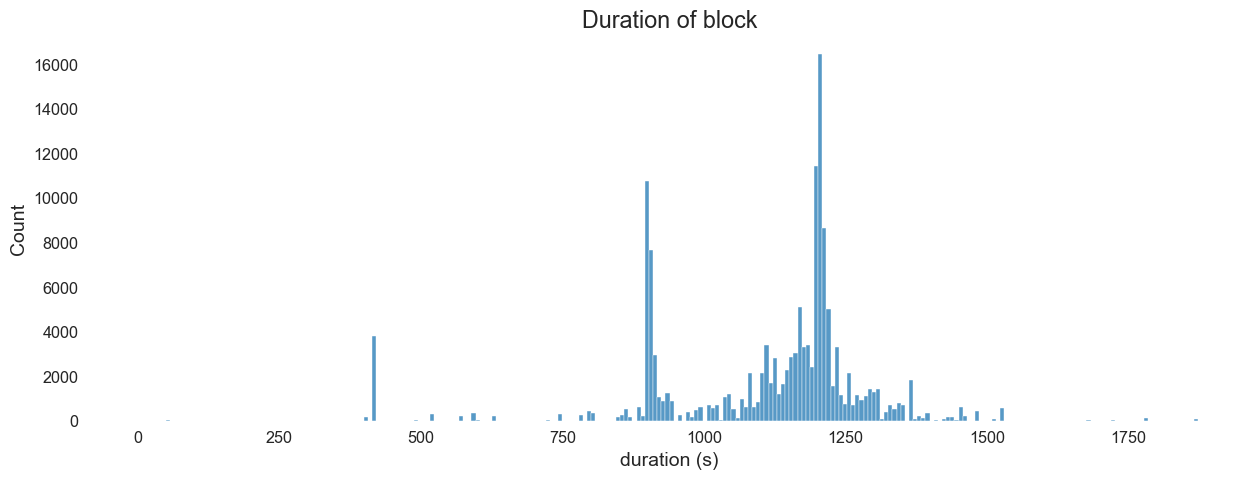

In [4]:
sns.histplot(df, x = 'duration')
plt.title("Duration of block")
plt.xlabel("duration (s)");

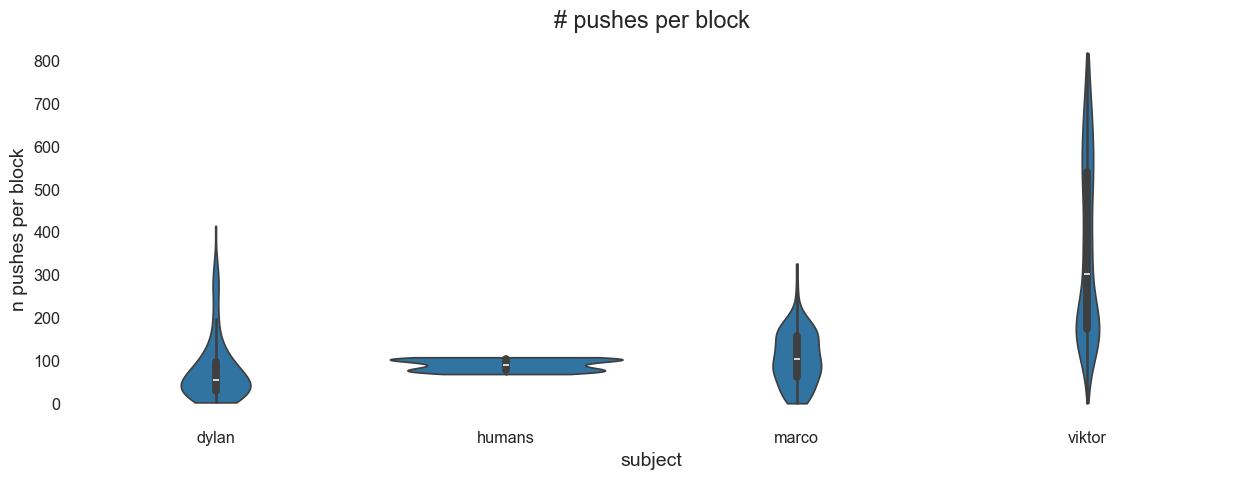

In [5]:
block_summary = df.groupby(['subject', 'session', 'block']).size().reset_index(name='n pushes per block')
sns.violinplot(block_summary, x='subject', y='n pushes per block', cut=0)
plt.title("# pushes per block");

Here is a bird's eye view of one subject's behavioral data over the course of the entire experiment. Each row is a session of consecutive blocks. Each block's pushes are displayed as a raster plot over the duration of that block, and the pushes at each box position are stacked on top of each other (top to bottom is 3, 2, 1). Finally, pushes are colored by box schedule, so we can see how the schedules are assigned to each box over consecutive blocks.

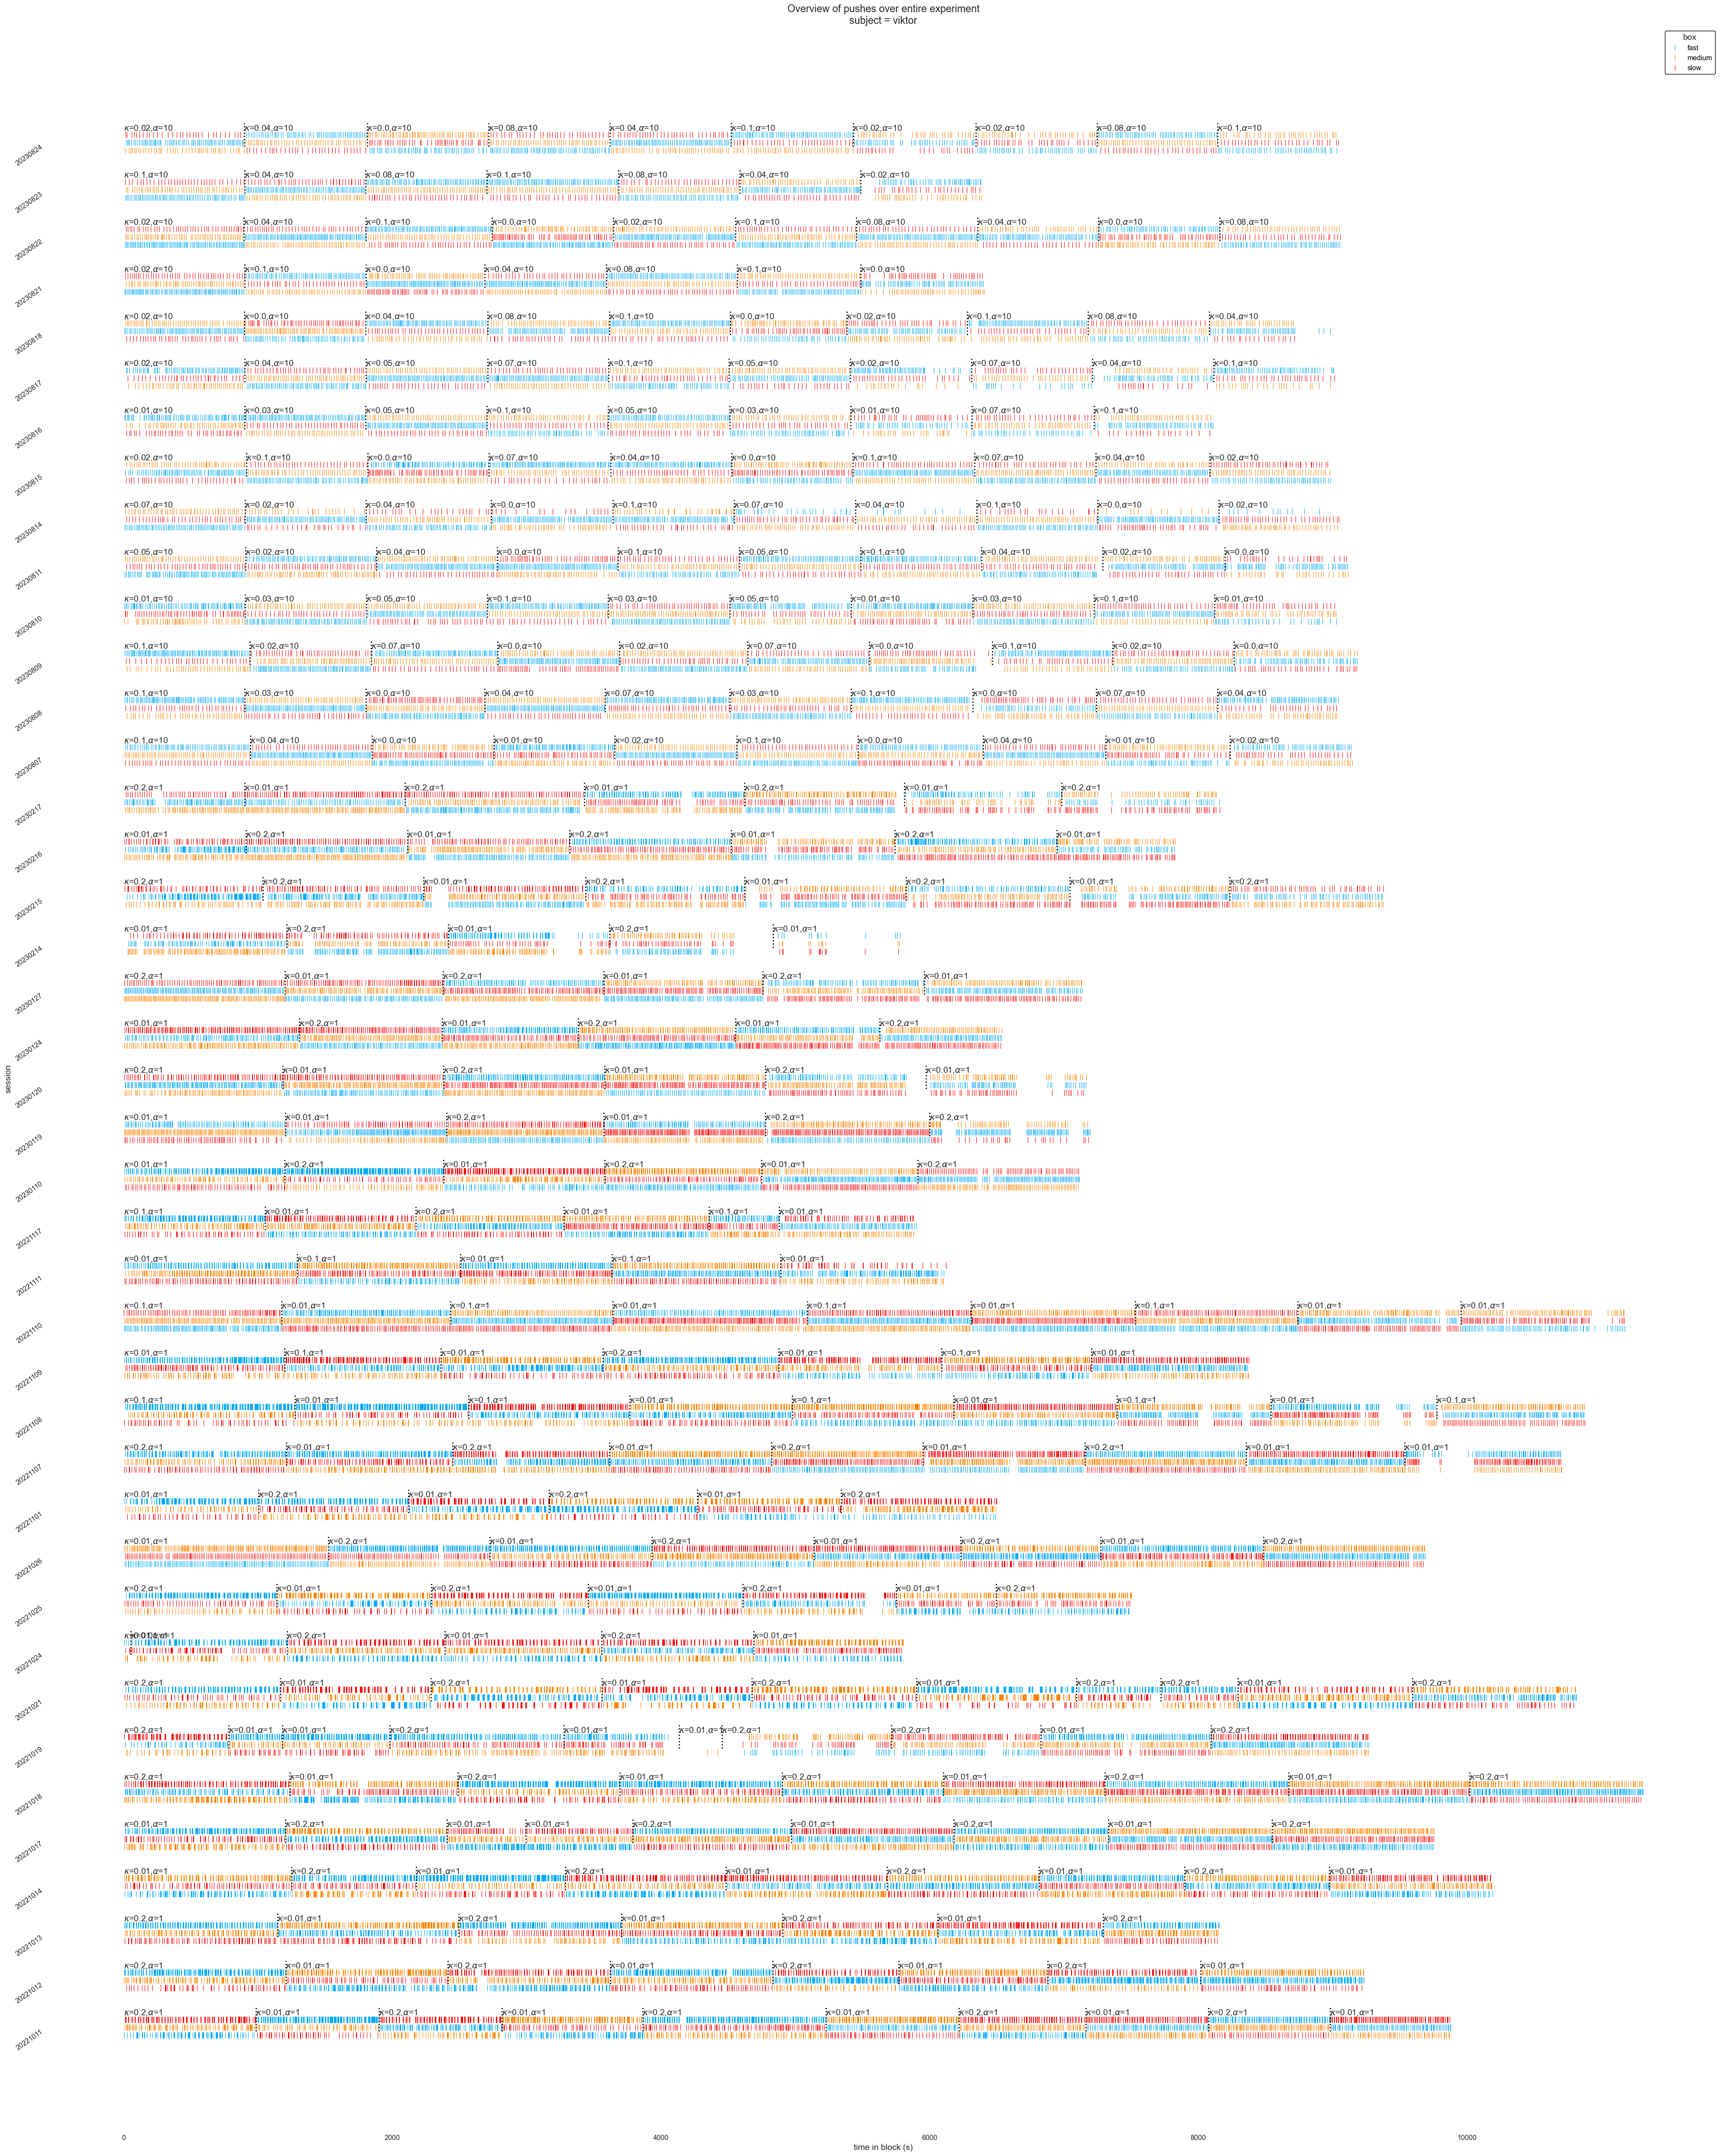

In [36]:
conds = dict(subject='viktor')
plot_experiment_overview(df, conds=conds, title_prefix='Overview of pushes over entire experiment', annotate_block=True,
                         fig_kwargs=dict(figsize=(40, 50)));

# Analyze Outliers

Before we get to the fun stuff of analyzing behavior, it is worth taking pains to clean the data by filtering out behavior that seems "off-task". This may seem counterproductive to the goal of analyzing free behavior, but there is a trade-off between the goals of modeling as much of the behavior as possible and having a simple model of a subset of "interesting" behavior. The goal of this notebook is to design a rudimentary exclusion criteria to isolate this subset of outliers. Intuitively, long bouts of time when the subject is not pushing should be indicative of off-task or "lapse" behavior. This is a vague criterion that we will refine by exploring the distribution of consecutive push intervals, the times between consecutive pushes.

Here, each subject's push intervals are shown on a logscale. The individual circles are outliers that would show up on a boxplot of the data, defined as all datapoints lying outside of 1.5*IQR (inter-quartile range) from the first and third quartile (in the original data space, not log).

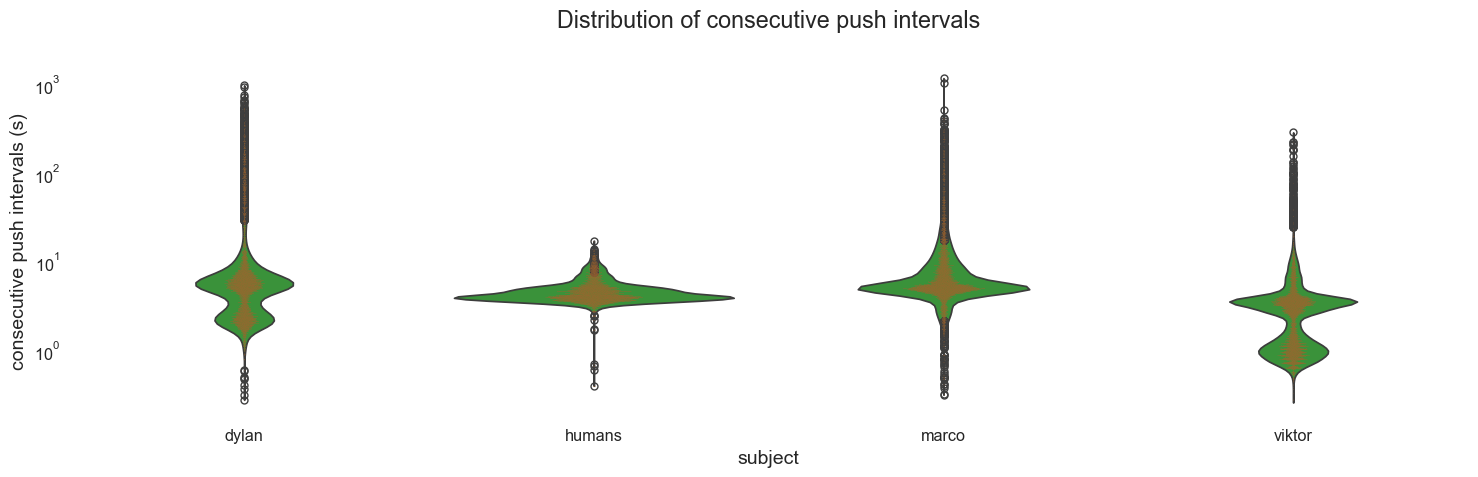

In [7]:
# Plot distribution of push intervals on log-scale
fig, ax = plt.subplots()
bp(sns.boxplot)(df, x='subject', y='consecutive push intervals', showcaps=False,
                showbox=False, log_scale=True, whiskerprops={'visible': False}, medianprops={'visible': False},
                legend=False, ax=ax)
bp(sns.swarmplot)(df.groupby('subject').sample(10000, random_state=SEED, replace=True), x='subject',
                  y='consecutive push intervals', legend=False, log_scale=True, size=0.25, dodge=True, ax=ax)
bp(sns.violinplot)(df, x='subject', y='consecutive push intervals', cut=0,
                   inner=None, log_scale=True, title_prefix="Distribution of consecutive push intervals",
                   y_unit='s', legend=False, ax=ax);

We see a mix of bimodality and unimodality among the subjects. Next, we will sort each push interval by the percentile at which it occurs in each subject's data.

dylan's 92.5% push 33.75299999996787
humans's 99.0% push 10.417100000000005
marco's 95.0% push 26.90300000004936
viktor's 99.9% push 32.09999999997672


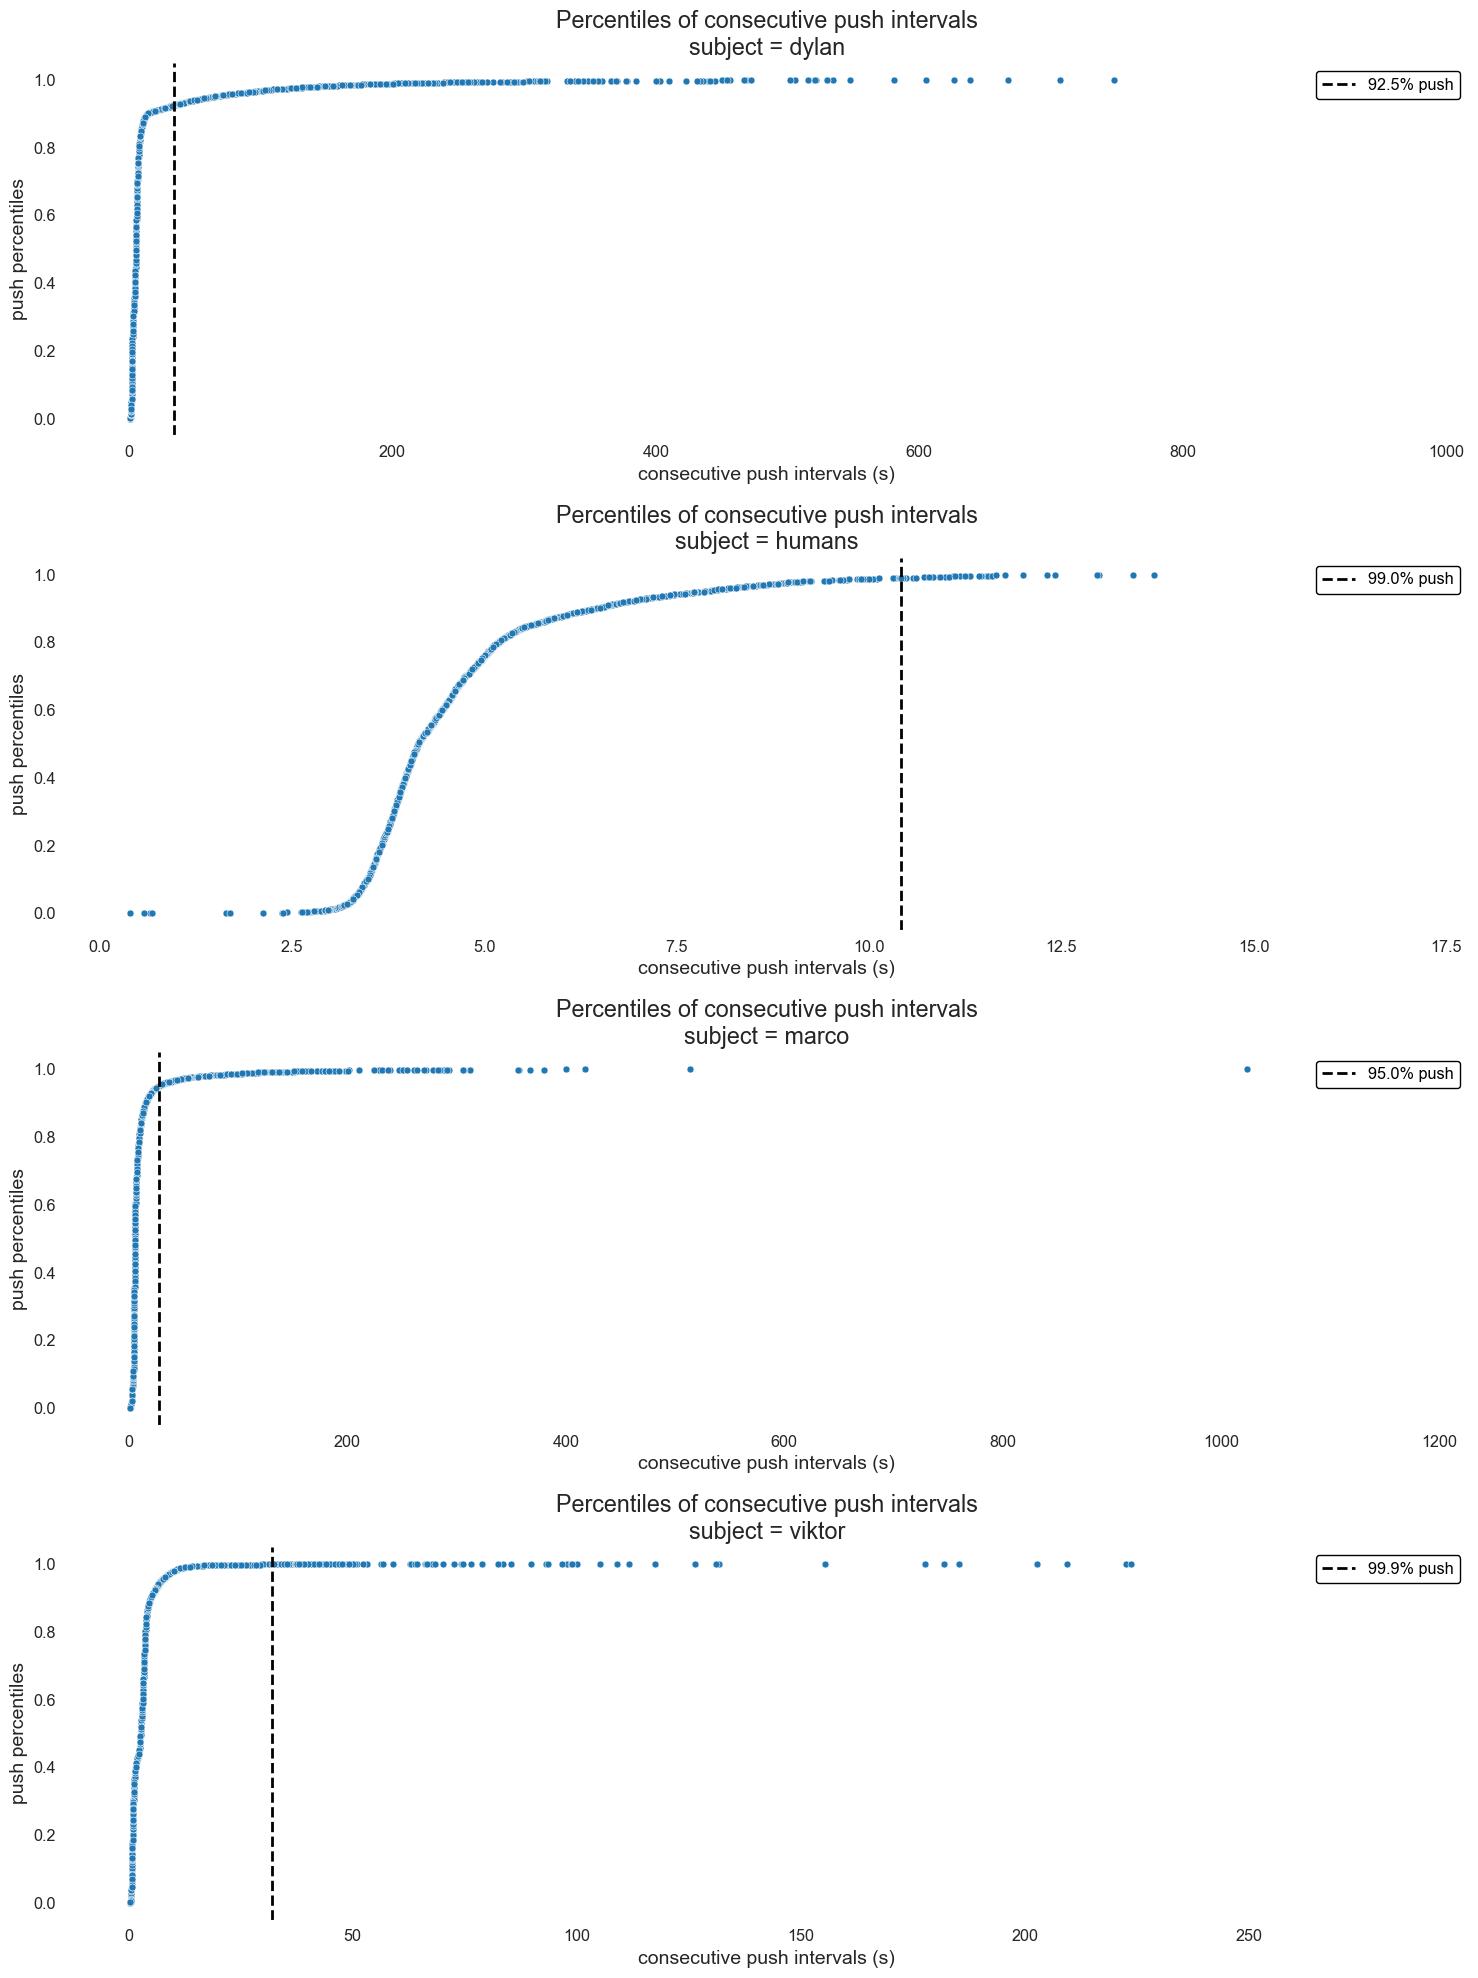

In [43]:
# Sort pushes by percentiles
df['push percentiles'] = df.groupby('subject', as_index=False)['consecutive push intervals'].rank(pct=True)
subjects = df.index.unique('subject')
percentiles = dict(zip(subjects,[0.925, 0.99, 0.95, 0.999]))
fig, axes = plt.subplots(len(subjects), 1, figsize=(15, 20))
for i, subj in enumerate(subjects):
    bp(sns.scatterplot)(df, x='consecutive push intervals', y='push percentiles', conds={'subject': subj}, title_prefix="Percentiles of consecutive push intervals", x_unit='s', ax=axes[i], legend = False)
    y = df.loc[(subj,), 'push percentiles'].sort_values()
    x = df.loc[(subj,), 'consecutive push intervals'].sort_values()

    percentile = percentiles[subj]
    perc_idx = np.argmin((y - percentile)**2)
    push_perc = x.iloc[perc_idx]
    print(f'{subj}\'s {round(percentile * 100, 2)}% push {push_perc}')
    axes[i].axvline(push_perc, color='black', linestyle='dashed', label=f'{round(percentile * 100, 2)}% push')
    axes[i].legend(loc = 'upper right')
fig.tight_layout();

Each subject has different percentiles when similarly large push intervals emerge. Aside from the humans, whose percentile curves are characteristic of a gaussian, the other subjects are heavily non-gaussian. To get a better sense of an appropriate boundary between regular pushes and outliers, we will consider the characteristics of example blocks containing the longest push intervals.

## Example Blocks

Here are the blocks that contain the top push intervals for each subject. Each push is labeled by its reward outcome, with filled symbols indicating reward and empty no reward, and is colored by the schedule of the box they occur at. Dashed lines connect consecutive pushes.


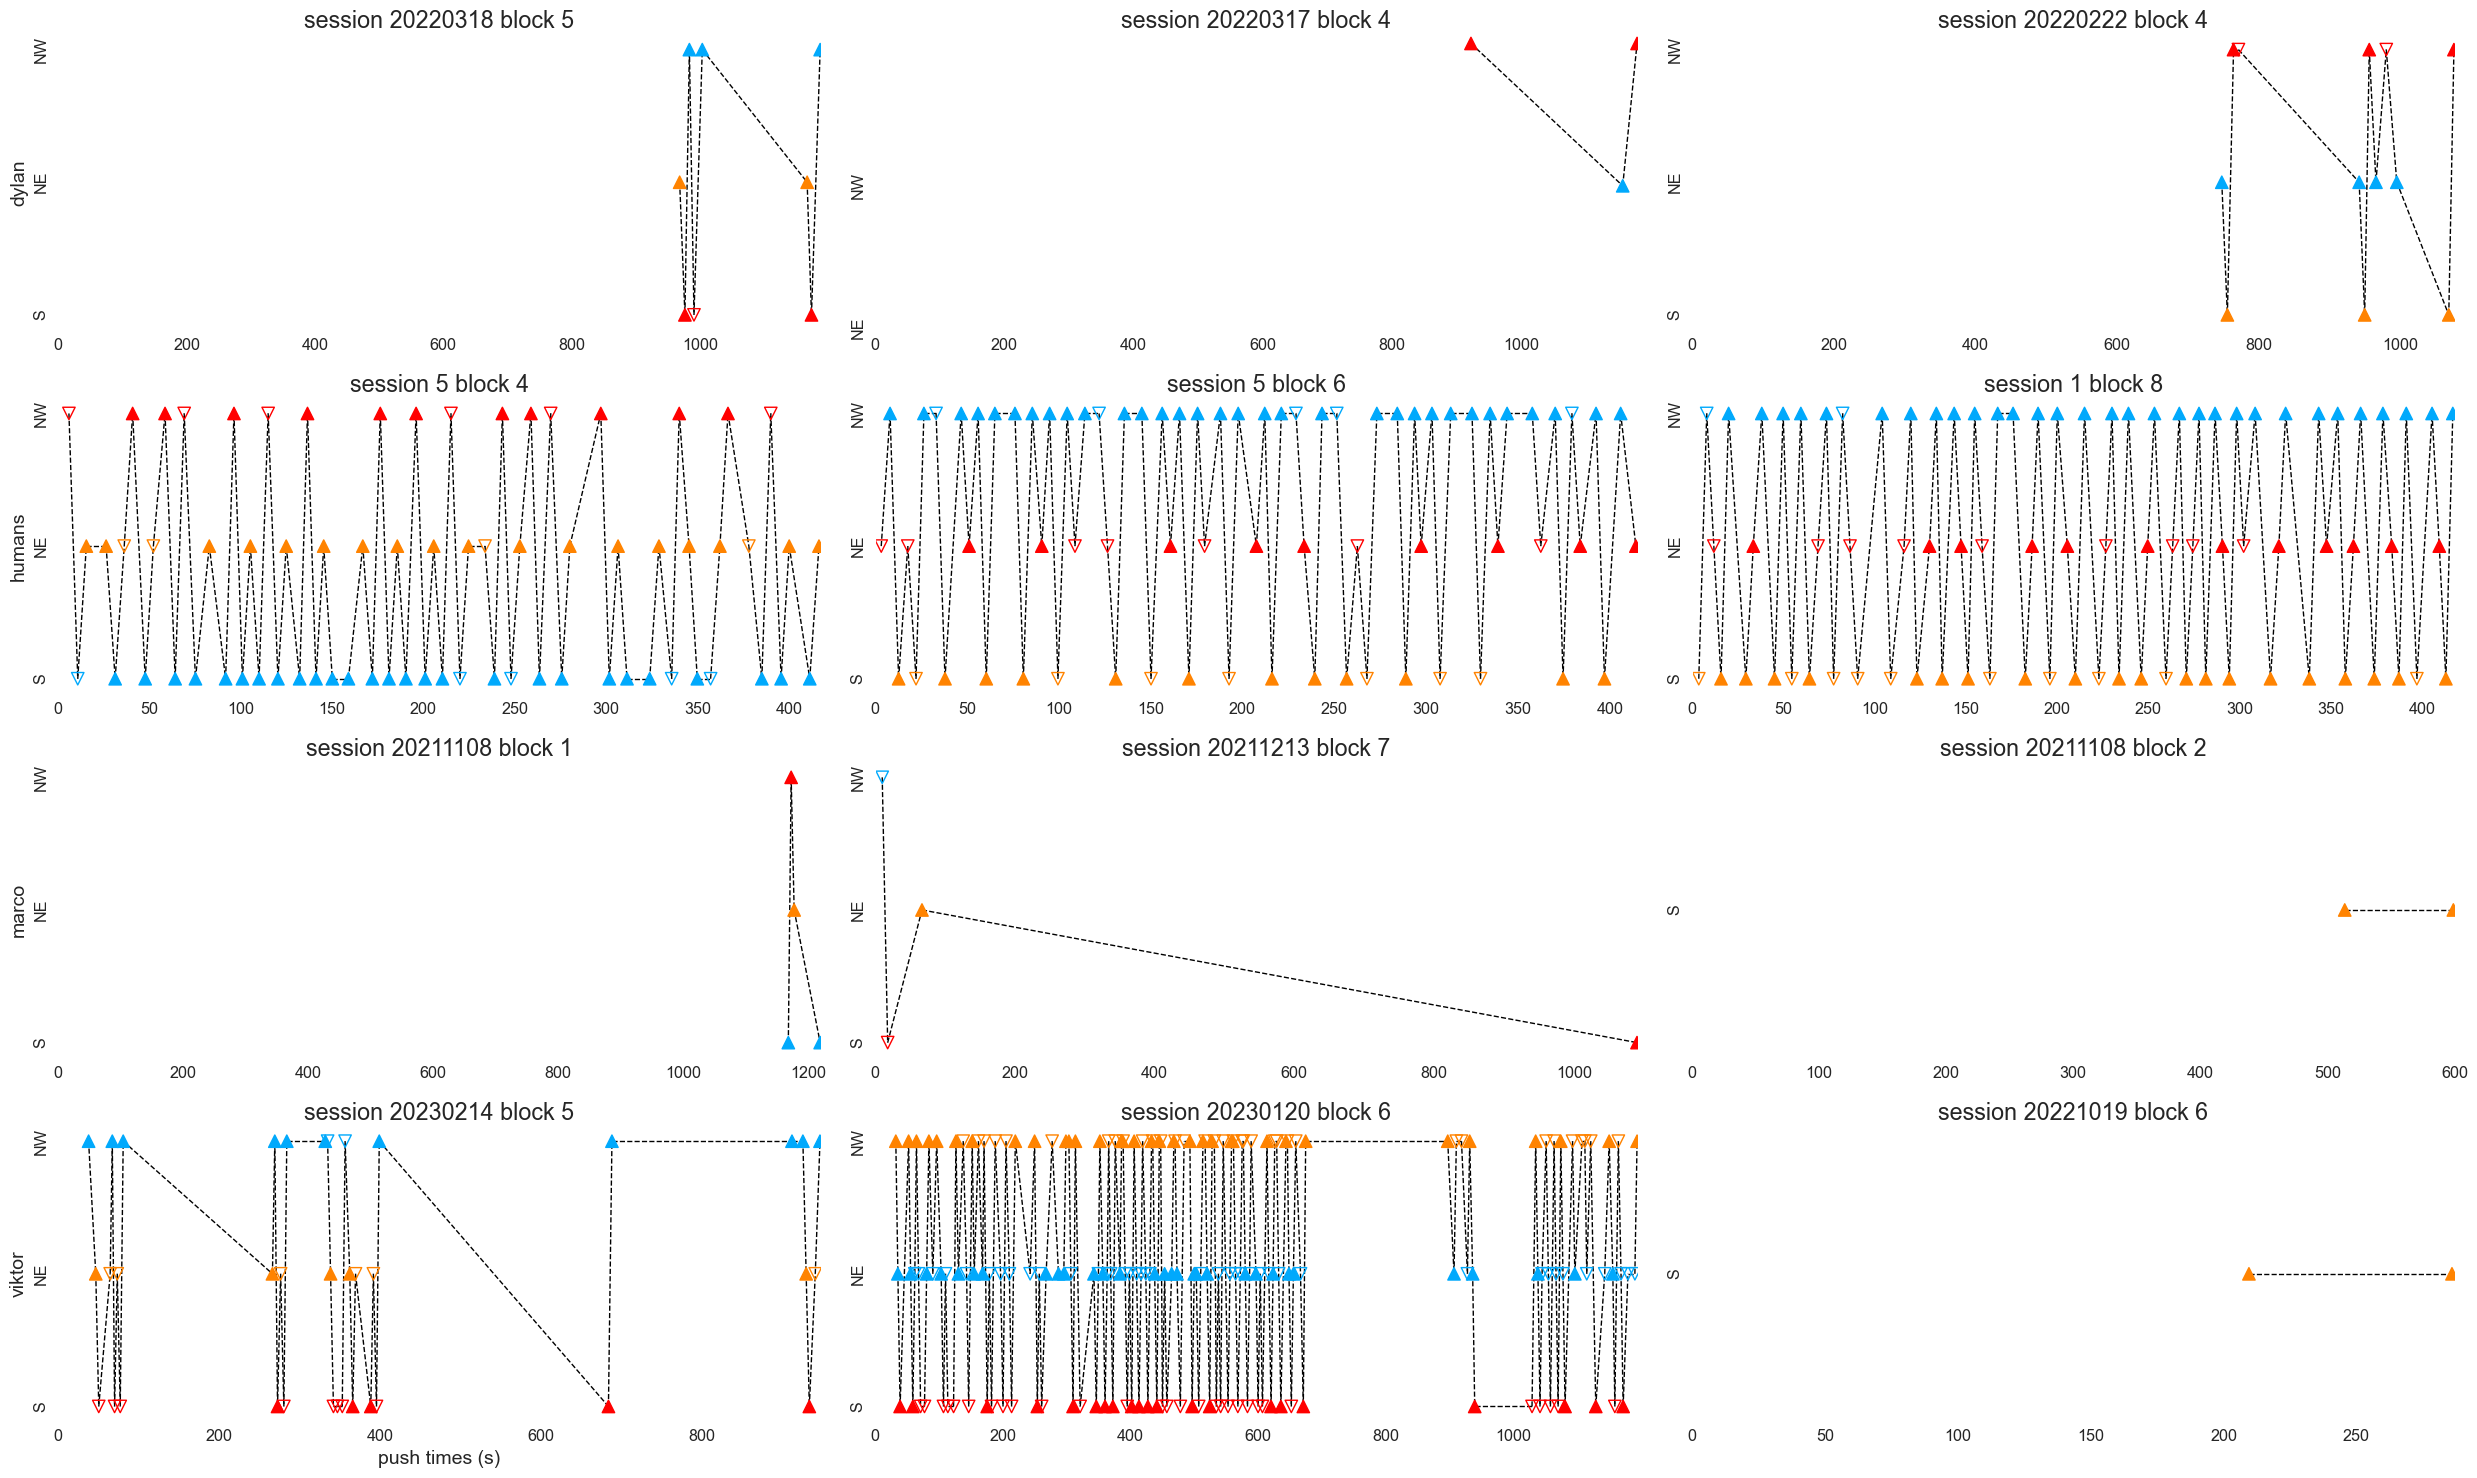

In [44]:
# Sort push intervals in descending order (longest push intervals at the top)
df_sorted = df.sort_values(by='consecutive push intervals', ascending=False)
#todo: wrap in own function in behavior.py
# Plot blocks containing the top_n push intervals
top_n = 3
fig, axes = plt.subplots(len(subjects), top_n, figsize=(25, 15))
for i, subject in enumerate(subjects):
    df_subject = filter_df(df_sorted, {'subject': subject}, attempt_index=False)
    for j, (idx, g) in enumerate(get_blocks(df_subject, sort=False)):
        if j >= top_n:
            break
        conds = dict(zip(INDEX[:MIN_INDEX - 1], idx))
        plot_pushes(g.sort_index(), conds=conds, title_prefix='', legend=False, ax=axes[i, j])
        axes[i, j].set_title(f"session {conds['session']} block {conds['block']}")
        if not i * top_n + j == (len(subjects) - 1) * top_n:
            axes[i, j].set_xlabel("")
            axes[i, j].set_ylabel("")
        if j == 0:
            axes[i, j].set_ylabel(subject)
fig.tight_layout();

Some push intervals appear long because the subject doesn't initiate the task for a long time. We will show the distribution of initiation times next. Also, some blocks are very sparse while other blocks have long segments of task-engaged behavior interrupted by long breaks when the monkey does not push. One consideration for the exclusion criteria is to drop blocks that contain fewer than n pushes e.g. 10 pushes, even if there are a couple "reasonable looking" pushes; it's very likely the animal is actually disengaged the entirety of that block, thus casting doubt on any reasonable behavior appearing in that block. For blocks that are denser in pushes, we need a different criteria.

## Block Initiation

Here we show the distribution of times when the first push in the block occurs for each subject on logscale.



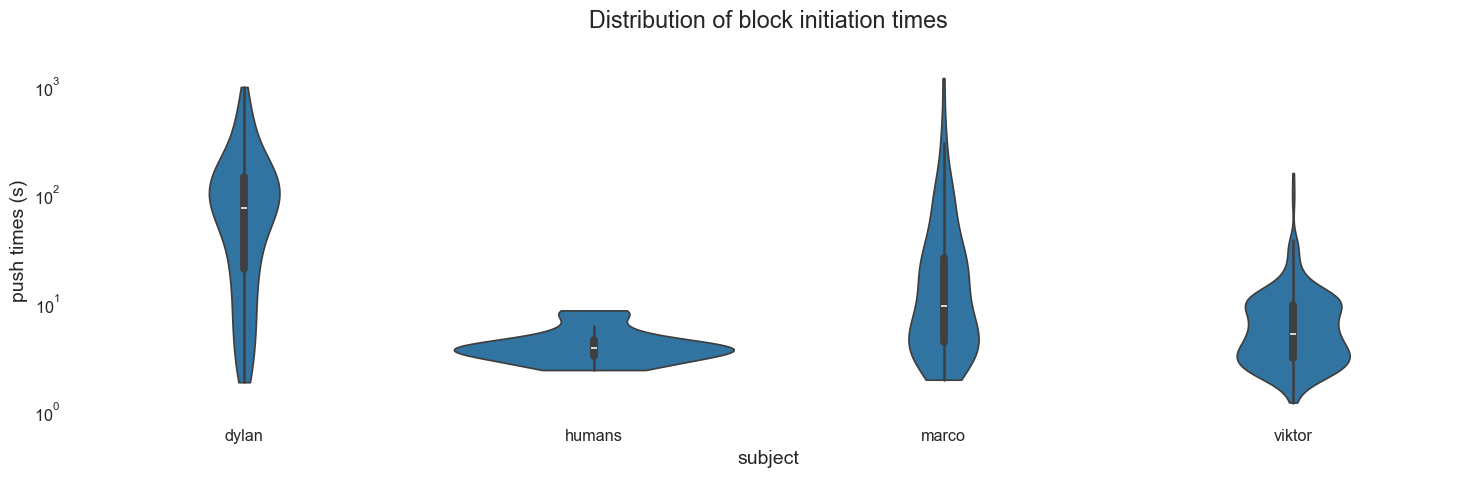

In [10]:
# Plot distribution of push intervals on log-scale
fig, ax = plt.subplots()
df_init = df.xs(1, level = 'push #')
bp(sns.violinplot)(df_init, x='subject', y='push times', cut=0, log_scale=True, title_prefix="Distribution of block initiation times", y_unit='s', legend=False, ax=ax);

Dylan appears to initiate the block extremely late compared to other subjects, with a mode around 100 s. Marco also seems to have a decent chunk of blocks which are initiated after 100 s. Next, we'll consider possible correlates of long push intervals, such as reward and spatial position.

## Reward

Now we will compare the relationship between reward and lapses for the top push intervals and a control group of "normal" push intervals sampled from the middle 50%. First, for each push, we will consider the fraction of rewarded pushes in the last 30 seconds preceding the onset of the push interval (which is when the *previous* push occurs), because we are interested in seeing whether satiety up until this point can predict that the next push will be longer than usual. If the reward fraction is particularly high in the top push intervals compared to the control, then it's possible that the subject is satiated and thus more likely disengage from the task for some time. We will also consider the effect of disappointing outcomes on the likelihood of lapsing-- if, among the unrewarded outcomes prior to the top push intervals, the subject waited longer to push a specific box compared to the control and still did not receive reward, then this could be indicative of disappointment playing a role in triggering lapses.

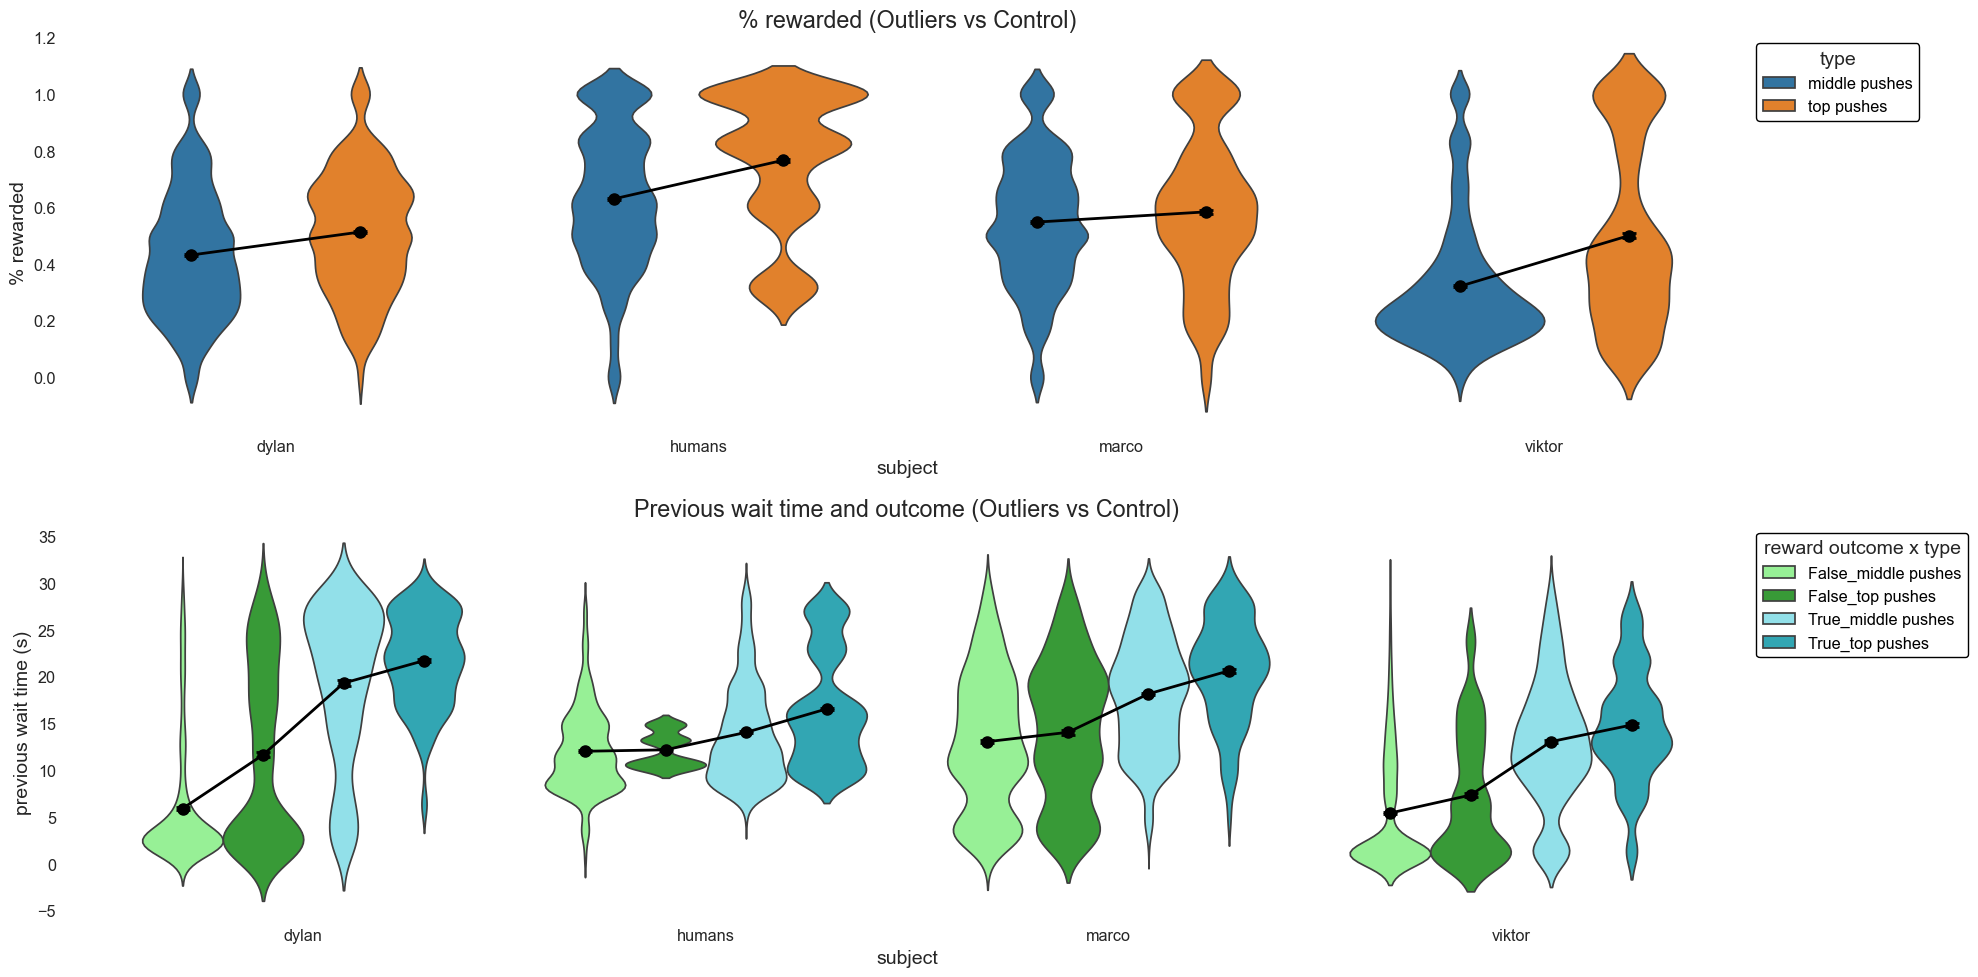

In [41]:
n_samples = 5000  # Sample n pushes
window = 30  # Time-window preceding pushes to calculate the reward rate, in seconds
df_rate_content = {'subject': [], 'push intervals': [], '% rewarded': [], 'previous wait time (s)': [], 'previous reward outcome': [], 'type': []}
outlier_label = "top pushes"
control_label = "middle pushes"

# For each subject, find the top x% pushes and calculate the reward fraction of the past `window` seconds prior to this push's onset
for i, subject in enumerate(subjects):
    df_subject = filter_df(df, {'subject': subject}, attempt_index=False)
    percentile = percentiles[subject]
    df_subject = df_subject[df_subject['push percentiles'] >= percentile]
    for idx, row in df_subject.sample(n_samples, replace = True).iterrows():

        # Get push immediately before current push
        push_num = idx[INDEX.index('push #')]
        new_idx = df.index.get_loc(idx) - 1
        if push_num == 1:
            continue

        # Calculate reward fraction within a given time window of the previous push
        new_row = df.iloc[new_idx]
        if new_row['push percentiles'] > 0.75: # if previous push is also outlier, then considering this push is redundant
            continue

        df_block = df.loc[idx[:MIN_INDEX - 1]]
        df_window = df_block.loc[(df_block['push times'] <= new_row['push times']) & (
                df_block['push times'] >= new_row['push times'] - window)]

        # Populate data arrays
        if len(df_window) > 0:
            df_rate_content['subject'].append(subject)
            df_rate_content['push intervals'].append(row['consecutive push intervals'])
            df_rate_content['% rewarded'].append(df_window['reward outcomes'].sum() / len(df_window['reward outcomes']))
            df_rate_content['previous wait time (s)'].append(new_row['wait times'])
            df_rate_content['previous reward outcome'].append(new_row['reward outcomes'])
            df_rate_content['type'].append(outlier_label)

# Also sample from the middle 50% as a control
for i, subject in enumerate(subjects):
    df_subject = filter_df(df, {'subject': subject}, attempt_index=False)
    df_subject = df_subject[(df_subject['push percentiles'] >= 0.25) & (df_subject['push percentiles'] <= 0.75)]
    for idx, row in df_subject.sample(n_samples, replace = True).iterrows():

        # Get push immediately before current push
        push_num = idx[INDEX.index('push #')]
        new_idx = df.index.get_loc(idx) - 1
        if push_num == 1:
            continue

        # Calculate reward fraction within a given time window of the previous push
        new_row = df.iloc[new_idx]
        df_block = df.loc[idx[:MIN_INDEX - 1]]
        df_window = df_block.loc[(df_block['push times'] <= new_row['push times']) & (
                df_block['push times'] >= new_row['push times'] - window)]

        # Populate data arrays
        if len(df_window) > 0:
            df_rate_content['subject'].append(subject)
            df_rate_content['push intervals'].append(row['consecutive push intervals'])
            df_rate_content['% rewarded'].append(df_window['reward outcomes'].sum() / len(df_window['reward outcomes']))
            df_rate_content['previous wait time (s)'].append(new_row['wait times'])
            df_rate_content['previous reward outcome'].append(new_row['reward outcomes'])
            df_rate_content['type'].append(control_label)

# Plot reward fraction and disappointment
fig, axes = plt.subplots(2, 1, figsize = (20, 10))
df_rate = pd.DataFrame(df_rate_content).set_index('subject').dropna()
df_rate = df_rate[df_rate['previous wait time (s)'] <= 30]
enhanced_violinplot(df_rate, x='subject', y='% rewarded', hue = 'type', hue_order = [control_label, outlier_label], ax = axes[0], inner = None)
axes[0].set_title(f"% rewarded (Outliers vs Control)")
sns.move_legend(axes[0], "upper left", bbox_to_anchor = (1,1))

df_rate['reward outcome x type'] = df_rate['previous reward outcome'].astype(str) + '_' + df_rate['type']
enhanced_violinplot(df_rate, x='subject', y='previous wait time (s)', hue = 'reward outcome x type', ax = axes[1], palette = ['#89ff87', '#28ab26', '#84ebf7', '#1cb7c9'], hue_order = ['False_'+control_label, 'False_'+outlier_label, 'True_'+control_label, 'True_'+outlier_label],  density_norm = 'width', inner = None)
axes[1].set_title(f"Previous wait time and outcome (Outliers vs Control)")
sns.move_legend(axes[1], "upper left", bbox_to_anchor = (1,1))
fig.tight_layout();

The top push intervals for most subjects are preceded by a higher fraction of rewarded pushes compared to the control, suggesting satiety could be triggering lapses. Also, the unrewarded outcomes preceding the top push intervals are associated with more disappointing outcomes, as the subjects tend to wait longer compared to control. It's also interesting to see that among rewarded outcomes, the subjects also wait longer in the top group than in the control group, which goes hand-in-hand with observing a higher reward fraction (recall the reward fraction looks at the number of rewarded outcomes in the past 30 seconds preceding the previous push, not necessarily the reward per unit time). Next, we will consider temporal and spatial correlates of the lapses: First, we'll show the distribution of the onset of push intervals in the session, and then we will see whether there is a correlation between push intervals and positions occupied in the arena.

## Time
Here we show the distribution of push onsets in each session for each subject, separated once again by top vs middle push intervals.

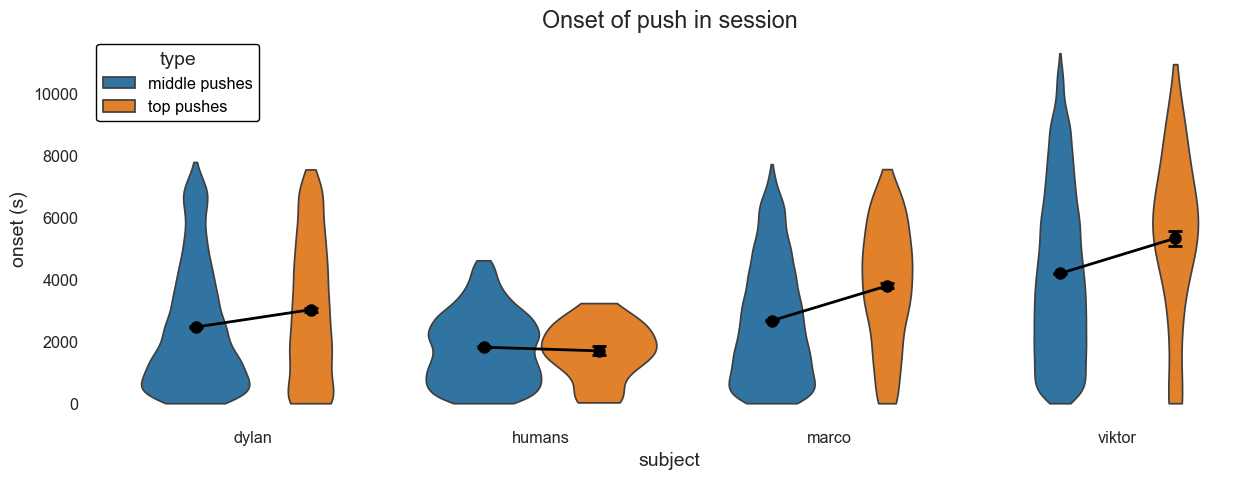

In [42]:
# Get time of each push in the session, not just block
x_offset = get_blocks(df)['duration'].last()
x_offset.iloc[1:] = x_offset.groupby(['subject', 'session']).cumsum().iloc[:-1]
session_start = x_offset.reset_index(level='block').groupby(['subject','session'])['block'].first()
for idx, x in session_start.items(): # Make sure each row (session) starts from 0 on the x-axis
    x_offset.loc[idx + (x,)] = 0
df_temp = df.join(x_offset, rsuffix = '_offset', on=INDEX[:MIN_INDEX-1])
df_temp['push time in session'] = df_temp['push times'] + df_temp['duration_offset']
df_temp['onset (s)'] = get_blocks(df_temp['push time in session']).shift().fillna(0)

# Compare top pushes and middle pushes
df_temp_content = []
for i, subject in enumerate(subjects):
    percentile = percentiles[subject]
    df_subject = filter_df(df_temp, {'subject': subject}, attempt_index=False)
    df_subject = df_subject[(df_subject['push percentiles'] >= percentile) | ((df_subject['push percentiles'] >= 0.25) & (df_subject['push percentiles'] <= 0.75))]
    df_subject.loc[df_subject['push percentiles'] >= percentile, 'type'] = outlier_label
    df_subject.loc[(df_subject['push percentiles'] >= 0.25) & (df_subject['push percentiles'] <= 0.75), 'type'] = control_label
    df_temp_content.append(df_subject)
df_temp = pd.concat(df_temp_content)
ax = enhanced_violinplot(df_temp, x = 'subject', y = 'onset (s)', hue = 'type', hue_order = [control_label, outlier_label], cut = 0, inner = None)
ax.set_title('Onset of push in session');

For most subjects, the onsets of the top pushes are greater than the onsets of the middle pushes, suggesting that lapses may tend to occur later in the session.

## Space
Below is an example block containing a couple long push intervals occurring around 200 s and 800 s when the monkey climbs up in the arena.

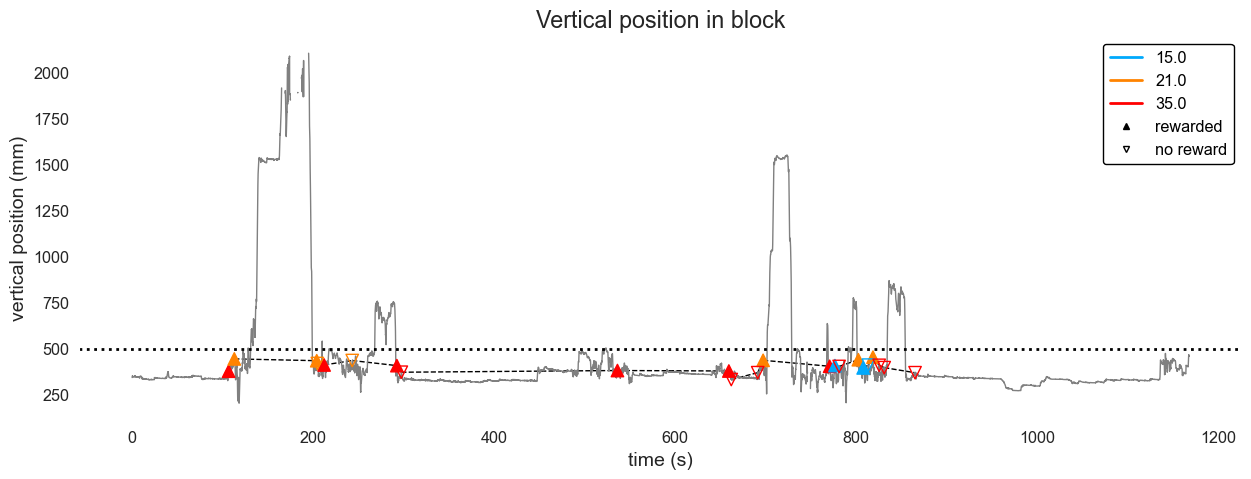

In [13]:
conds = {'subject': 'marco', 'session': 20211221, 'block': 6}
df_block = filter_df(df, conds).copy()
continuous_data, errors = get_continuous_from_df_to_dict(df_block, EXPERIMENT_DIR)
time = continuous_data[tuple(conds.values())]['time']
vertical = continuous_data[tuple(conds.values())]['position'][:,2]

# Plot all vertical positions
fig, ax = plt.subplots()
ax.plot(time, vertical, c = 'grey', linewidth = 1)

# Plot vertical position at time of push
idx = np.abs(time[None, :] - df_block['push times'].values[:, None]).argmin(axis=1)
df_block['z-coordinate'] = vertical[idx]
ax = plot_block_events(df_block, conds=conds, y='z-coordinate', y_unit='mm', title_prefix = 'Vertical position in block', ax = ax)
ax.axhline(y=500, label = 'screen', linestyle = ':', c = 'black')
ax.set_xlabel("time (s)")
ax.set_ylabel("vertical position (mm)")
ax.set_title("Vertical position in block");

Now we aggregate over multiple blocks, taking the average vertical position occupied during push intervals.

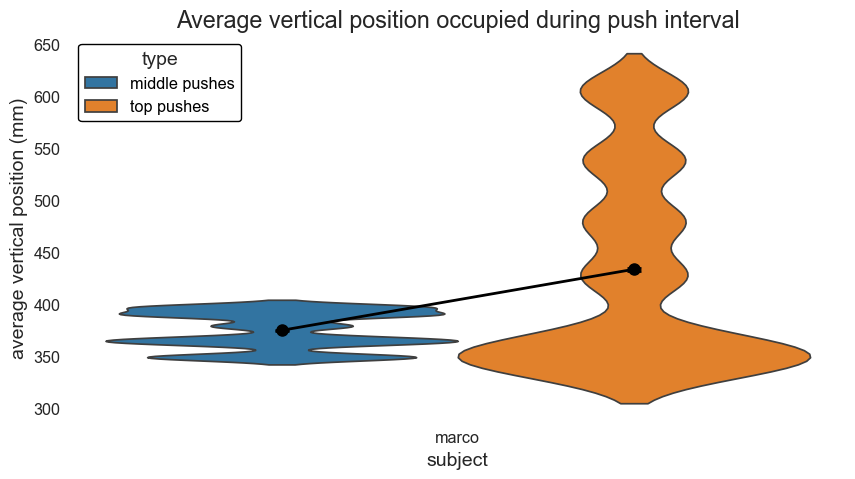

In [34]:
n_samples = 5000
df_vertical = {'subject': [], 'push intervals': [], 'average vertical position (mm)': [], 'type': []}

dfs_cont = []
cont_blocks = list(continuous_data.keys())
for block in cont_blocks:
    dfs_cont.append(df.xs(block, level = ('subject', 'session', 'block'), drop_level = False))
df_cont = pd.concat(dfs_cont)

# For each subject, find the top x% pushes and calculate the reward fraction of the past `window` seconds prior to this push's onset
for i, subject in enumerate(subjects):
    df_subject = filter_df(df_cont, {'subject': subject}, attempt_index=False)
    percentile = 0.9
    df_subject = df_subject[df_subject['push percentiles'] >= percentile]
    if len(df_subject) == 0:
        continue
    for idx, row in df_subject.sample(n_samples, replace = True).iterrows():
        df_vertical['subject'].append(subject)
        df_vertical['push intervals'].append(row['consecutive push intervals'])

        # Identify the push times in vertical
        # Take average over each push interval
        conds = dict(subject=subject,session=idx[INDEX.index('session')], block = idx[INDEX.index('block')])
        time = continuous_data[tuple(conds.values())]['time']
        vertical = continuous_data[tuple(conds.values())]['position'][:,2]
        push_interval_end = row['push times']
        push_interval_start = push_interval_end - row['consecutive push intervals']
        x = np.abs(time[None, :] - np.array([[push_interval_start], [push_interval_end]])).argmin(axis=1)
        df_vertical['average vertical position (mm)'].append(vertical[x[0]:x[1]].mean())
        df_vertical['type'].append(outlier_label)

for i, subject in enumerate(subjects):
    df_subject = filter_df(df_cont, {'subject': subject}, attempt_index=False)
    df_subject = df_subject[(df_subject['push percentiles'] >= 0.25) & (df_subject['push percentiles'] <= 0.75)]
    if len(df_subject) == 0:
        continue
    for idx, row in df_subject.sample(n_samples, replace = True).iterrows():
        df_vertical['subject'].append(subject)
        df_vertical['push intervals'].append(row['consecutive push intervals'])

        # Identify the push times in vertical
        # Take average over each push interval
        conds = dict(subject=subject,session=idx[INDEX.index('session')], block = idx[INDEX.index('block')])
        time = continuous_data[tuple(conds.values())]['time']
        vertical = continuous_data[tuple(conds.values())]['position'][:,2]
        push_interval_end = row['push times']
        push_interval_start = push_interval_end - row['consecutive push intervals']
        x = np.abs(time[None, :] - np.array([[push_interval_start], [push_interval_end]])).argmin(axis=1)
        df_vertical['average vertical position (mm)'].append(vertical[x[0]:x[1]].mean())
        df_vertical['type'].append(control_label)
df_vertical = pd.DataFrame(df_vertical).set_index('subject').dropna()
fig, ax = plt.subplots(figsize = (10,5))
ax = enhanced_violinplot(df_vertical, x='subject', y='average vertical position (mm)', hue = 'type', hue_order = [control_label, outlier_label], inner = None, ax = ax)
ax.set_title("Average vertical position occupied during push interval");

The top pushes are weakly greater than the control.

## HMM Policy Identification

Dr. Zhe Li has been developing an automatic, data-driven way to identify patterns and clusters in the behavioral data. Fitting an HMM over a diverse set of policies, he has shared the probabilities of 2 policies over time in several blocks of Marco's behavior. Here, we overlay them on top of push intervals in a given block and observe what the HMM is picking out.


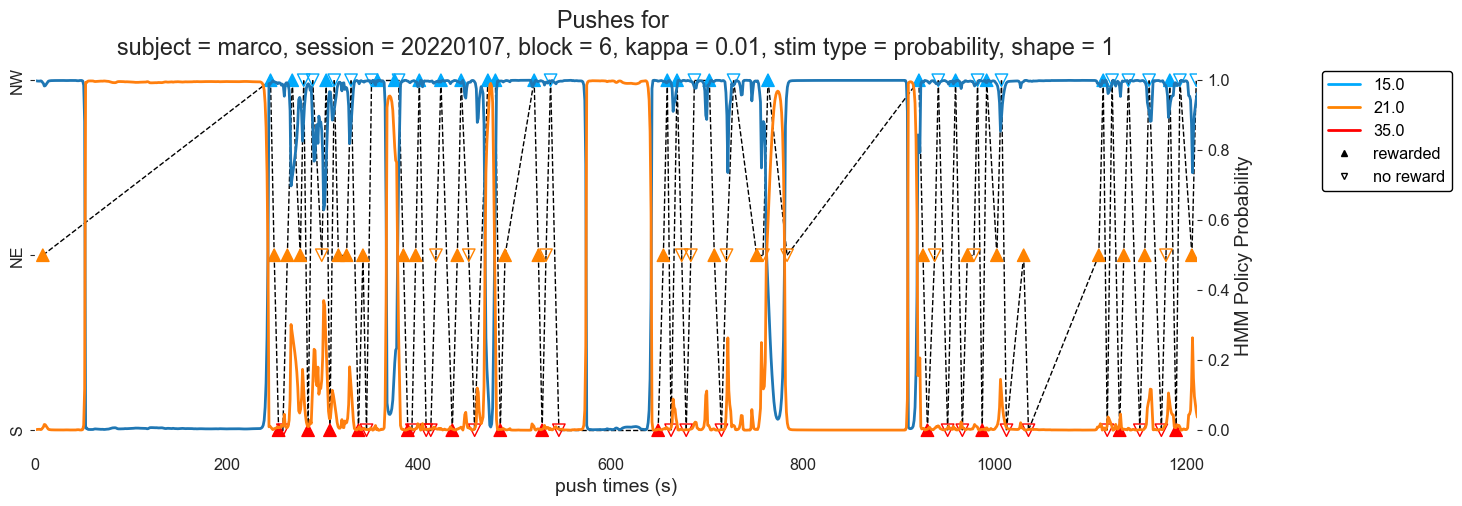

In [48]:
# Load HMM probabilities
with open(os.path.join(ANALYSIS_DIR, 'HMM.solution_[K2].pkl'), 'rb') as f:
    saved = pickle.load(f)

subject, kappa, block_ids = saved['subject'], saved['kappa'], saved['block_ids']
pos, gaze = saved['pos'], saved['gaze']
push, move, look = saved['push'], saved['move'], saved['look']
p_policy = saved['p_policy']

# Overlay probabilities on top of a specific block
block_idx = 30
session_id, block = block_ids[block_idx]
hmm_probs = p_policy[block_idx]
ax = plot_pushes(df, conds=dict(subject=subject, session=int(session_id), block=block + 1), legend_kwargs = {'loc': 'upper left', 'bbox_to_anchor': (1.1,1)})
ax2 = ax.twinx()
ax2.plot(hmm_probs)
ax2.set_ylabel('HMM Policy Probability');

# Clean Data

Taking all these observations into account, the following is a preliminary exclusion criteria:

+ remove all blocks with less than 10 pushes
+ remove all blocks where the schedules contain 80 s as one of the boxes
+ remove pushes greater than 30 s where the monkey is not pushing anything

This can be greatly expanded upon and refined through various data wrangling schemes, such as dimensionality reduction via PCA or t-SNE, and automated methods that we are currently developing. For now, this is a baseline criteria that serves as a starting point for more advanced analysis.

In [16]:
df_filtered = exclusion_criteria(df)
print(f'Applying exclusion criteria dropped {len(df) - len(df_filtered)} pushes')

Applying exclusion criteria dropped 3017 pushes


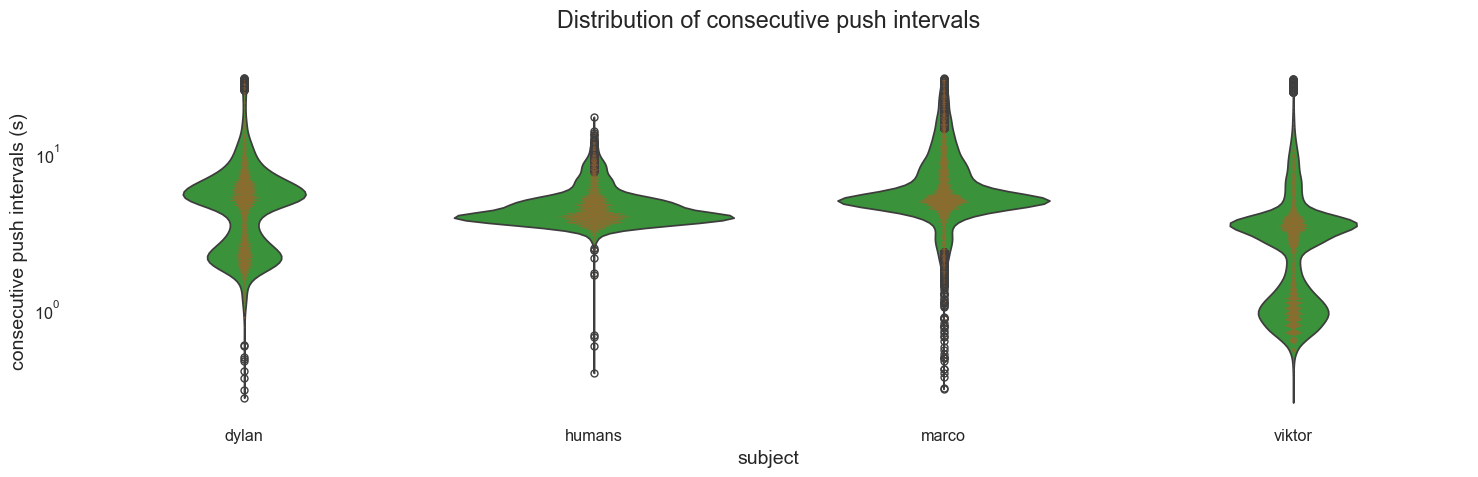

In [17]:
# Plot distribution of push intervals on log-scale
fig, ax = plt.subplots()
bp(sns.boxplot)(df_filtered, x='subject', y='consecutive push intervals', showcaps=False,
                showbox=False, log_scale=True, whiskerprops={'visible': False}, medianprops={'visible': False},
                legend=False, ax=ax)
bp(sns.swarmplot)(df_filtered.groupby('subject').sample(10000, random_state=SEED, replace=True), x='subject',
                  y='consecutive push intervals', legend=False, log_scale=True, size=0.25, dodge=True, ax=ax)
bp(sns.violinplot)(df_filtered, x='subject', y='consecutive push intervals', cut=0,
                   inner=None, log_scale=True, title_prefix="Distribution of consecutive push intervals",
                   y_unit='s', legend=False, ax=ax);

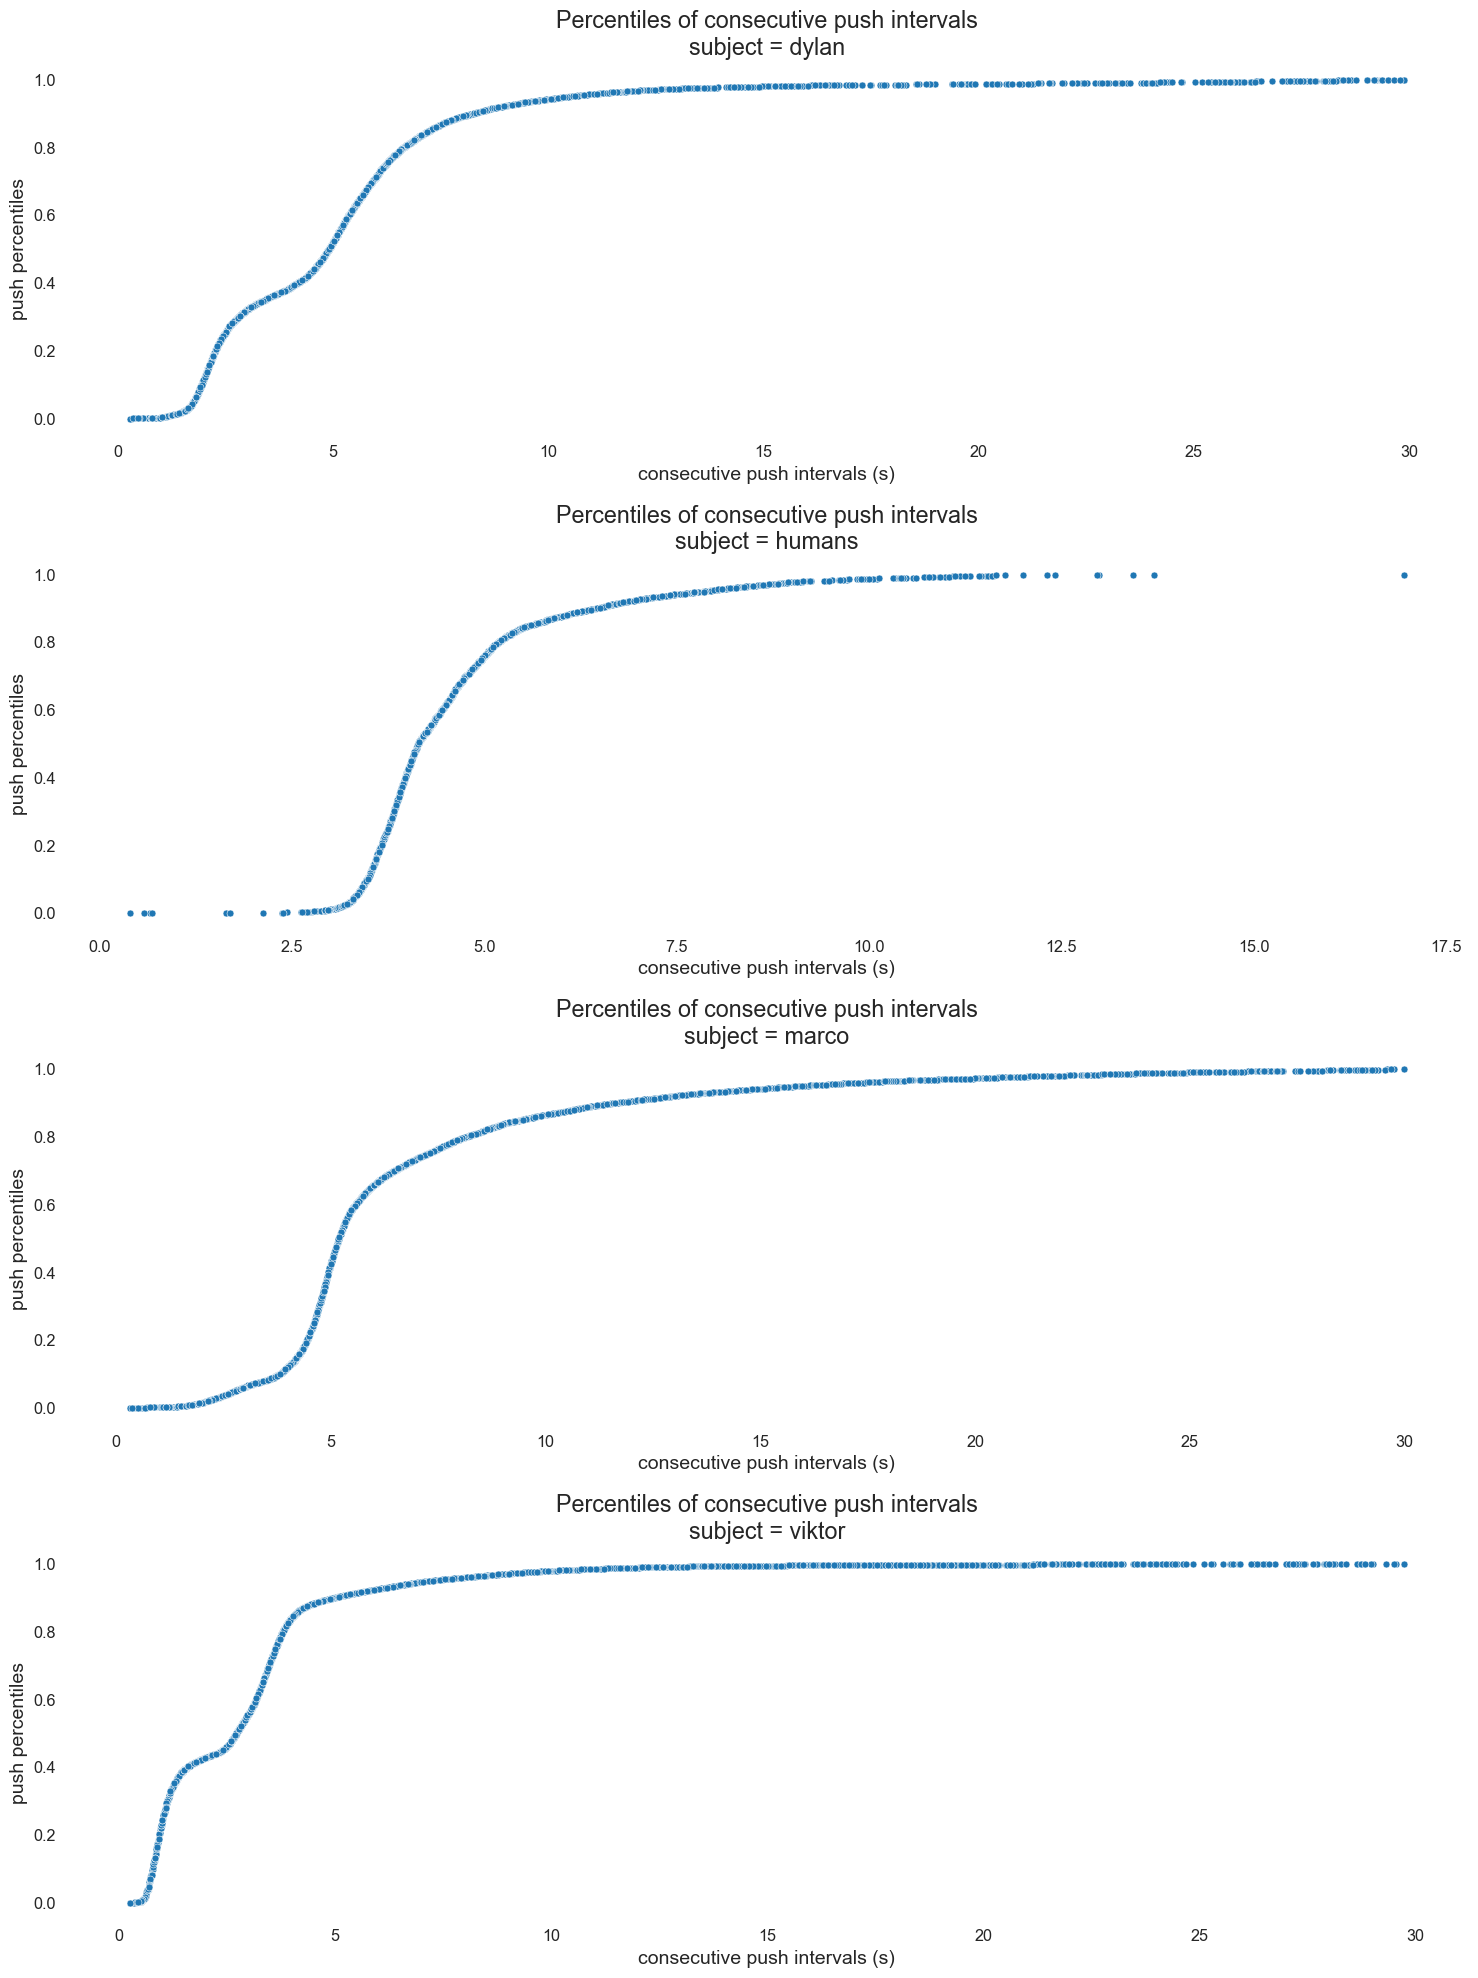

In [46]:
df_filtered['push percentiles'] = df_filtered.groupby('subject', as_index=False)['consecutive push intervals'].rank(pct=True)
subjects = df_filtered.index.unique('subject')
fig, axes = plt.subplots(len(subjects), 1, figsize=(15, 20))
for i, subj in enumerate(subjects):
    bp(sns.scatterplot)(df_filtered, x='consecutive push intervals', y='push percentiles', conds={'subject': subj}, title_prefix="Percentiles of consecutive push intervals", x_unit='s', ax=axes[i], legend = False)
fig.tight_layout();

Compared to the beginning of this notebook, after removing the outliers for each subject, we see now that the push intervals are within a more reasonable range and behave more like a gaussian.